## A* Algorithm

In [46]:
import heapq
import matplotlib.pyplot as plt

## 1. Create the grid
0 = free cell

1 = obstacle

In [47]:
grid = [
    [0,0,0,0,0],
    [0,1,1,0,0],
    [0,0,0,0,0],
    [0,1,0,1,0],
    [0,0,0,0,0]
]

In [48]:
start = (0,0)
goal = (4,4)

## 2. Heuristic function

In [49]:
def heuristic(a, b):
    return abs(a[0]-b[0])- abs(a[1]-b[1])

## A* Alogorithm

In [50]:
def astar(grid, start, goal):
    rows = len(grid)
    cols = len(grid[0])


## Priority queue

In [51]:
open_list=[]

## Add start node

In [52]:
heapq.heappush(open_list, (0, start))

In [53]:
came_from= {}
g_score = {start:0}
f_score = {
    start: heuristic(start, goal)
}
directions =[
    (-1,0),
    (1,0),
    (0,-1),
    (0,1)
    
]

In [54]:
def a_star(grid, start, goal):

    # Get the number of rows in the grid
    rows = len(grid)

    # Get the number of columns in the grid
    cols = len(grid[0])

    # Define the possible movement directions
    directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    # Store the priority queue for nodes waiting to be explored
    open_list = []

    # Store the cost from the start node to each node
    g_score = {start: 0}

    # Store the estimated total cost for each node
    f_score = {start: heuristic(start, goal)}

    # Store each node's parent for path reconstruction
    came_from = {}

    # Add the starting node to the priority queue
    heapq.heappush(open_list, (f_score[start], start))

    # Continue searching while there are nodes to explore
    while open_list:

        # Remove the node with the lowest f-score
        current_f, current = heapq.heappop(open_list)

        # Check if we have reached the goal
        if current == goal:

            # Create an empty list to store the path
            path = []

            # Follow the parent nodes back to the start
            while current in came_from:
                path.append(current)
                current = came_from[current]

            # Add the starting node
            path.append(start)

            # Reverse the path from start -> goal
            path.reverse()

            # Return the final path
            return path

        # Explore every possible direction
        for dr, dc in directions:

            # Get the current row and column
            r, c = current

            # Calculate the neighbor's row
            nr = r + dr

            # Calculate the neighbor's column
            nc = c + dc

            # Check that the neighbor is inside the grid and walkable
            if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:

                # Create the neighbor coordinate
                neighbor = (nr, nc)

                # Calculate the cost of reaching the neighbor
                tentative_g = g_score[current] + 1

                # Check if this is a cheaper path to the neighbor
                if tentative_g < g_score.get(neighbor, float("inf")):

                    # Store the current node as the neighbor's parent
                    came_from[neighbor] = current

                    # Update the cost to reach the neighbor
                    g_score[neighbor] = tentative_g

                    # Calculate f(n) = g(n) + h(n)
                    f = tentative_g + heuristic(neighbor, goal)

                    # Store the f-score
                    f_score[neighbor] = f

                    # Add the neighbor to the priority queue
                    heapq.heappush(open_list, (f, neighbor))

    # Return None if no path exists
    return None

In [57]:
path = a_star(grid, start, goal)
print("Path:\n")
print(path)

Path:

[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


In [68]:
def visualize_grid(grid, path, start, goal):
    plt.figure(figsize=(7, 7))

    # Display the grid
    plt.imshow(grid, cmap="gray_r")

    # Draw the path
    if path:
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(x, y, marker="o", linewidth=3)

    # Mark start and goal
    plt.scatter(start[1], start[0], marker="o", s=150, label="Start")
    plt.scatter(goal[1], goal[0], marker="X", s=150, label="Goal")

    # Show grid lines
    rows = len(grid)
    cols = len(grid[0])

    plt.xticks(range(cols))
    plt.yticks(range(rows))
    plt.grid(True)

    plt.legend()
    plt.title("A* Pathfinding")
    plt.show()

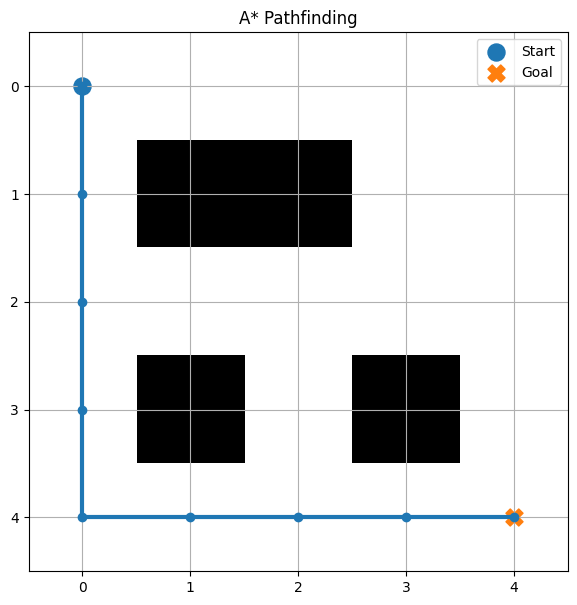

In [69]:
visualize_grid(grid, path, start, goal)